# Data Visualisation — Dataset augmenté

Analyse exploratoire du jeu de données **synthétique** : `data/augmented/champignons_augmented.csv`.

Objectifs :
1. Vérifier les distributions des features avant entraînement.
2. **Comparer** les statistiques aux données réelles (`champignons_clean.csv`) pour s'assurer que la génération est cohérente (même moyenne, même plage).

Le dataset augmenté contient N lignes par espèce (par défaut N = 1000), soit ~217 000 lignes.

## 1. Chargement

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

AUG_CSV   = "../../data/augmented/champignons_augmented.csv"
CLEAN_CSV = "../../data/clean_train_data/champignons_clean.csv"

df       = pd.read_csv(AUG_CSV)
df_clean = pd.read_csv(CLEAN_CSV)

print(f"Augmenté : {len(df):>7} lignes, {len(df.columns)} colonnes")
print(f"Réel     : {len(df_clean):>7} lignes, {len(df_clean.columns)} colonnes")
df.head(2)

## 2. Analyse des caractéristiques numériques (tailles)

Le dataset augmenté contient **une seule taille mesurée par partie** (`chapeau_taille_cm`, `pied_taille_cm`), tirée uniformément dans l'intervalle `[min, max]` de l'espèce. Vu le volume, on échantillonne 20 000 lignes pour alléger le rendu.

In [ ]:
size_cols = ["chapeau_taille_cm", "pied_taille_cm"]
df[size_cols].describe()

In [ ]:
sample = df.sample(min(20_000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(sample["chapeau_taille_cm"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution — chapeau_taille_cm (augmenté)")
axes[0].set_xlabel("cm")

sns.histplot(sample["pied_taille_cm"], bins=40, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution — pied_taille_cm (augmenté)")
axes[1].set_xlabel("cm")

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=sample[size_cols], ax=ax, palette="Set2")
ax.set_title("Boxplot des tailles (cm) — dataset augmenté")
ax.set_ylabel("cm")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 3. Analyse des caractéristiques catégorielles

### 3.1 Présence des attributs (binaires)

C:\Users\benja\AppData\Local\Temp\ipykernel_1928\2336399193.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")


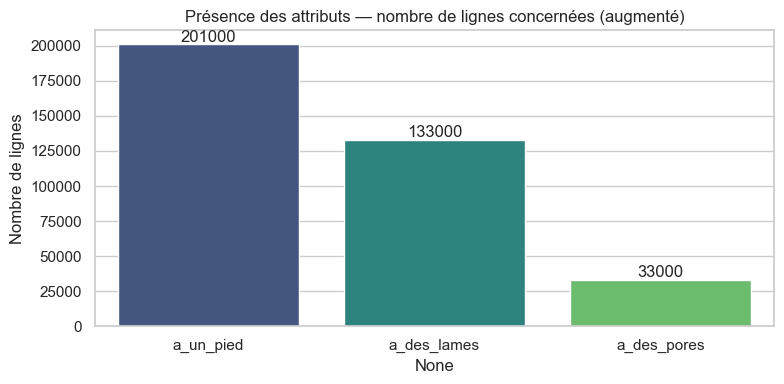

In [ ]:
binary_presence = ["a_un_pied", "a_des_pores", "a_des_lames"]
counts = df[binary_presence].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")
ax.set_title("Présence des attributs — nombre de lignes concernées (augmenté)")
ax.set_ylabel("Nombre de lignes")
for i, v in enumerate(counts.values):
    ax.text(i, v + (counts.max() * 0.01), f"{int(v)}", ha="center")
plt.tight_layout()
plt.show()

### 3.2 Top 10 des couleurs — chapeau et chair

C:\Users\benja\AppData\Local\Temp\ipykernel_1928\2919201950.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=chapeau_top.values, y=chapeau_top.index, ax=axes[0], palette="YlOrBr")
C:\Users\benja\AppData\Local\Temp\ipykernel_1928\2919201950.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=chair_top.values, y=chair_top.index, ax=axes[1], palette="PuRd")


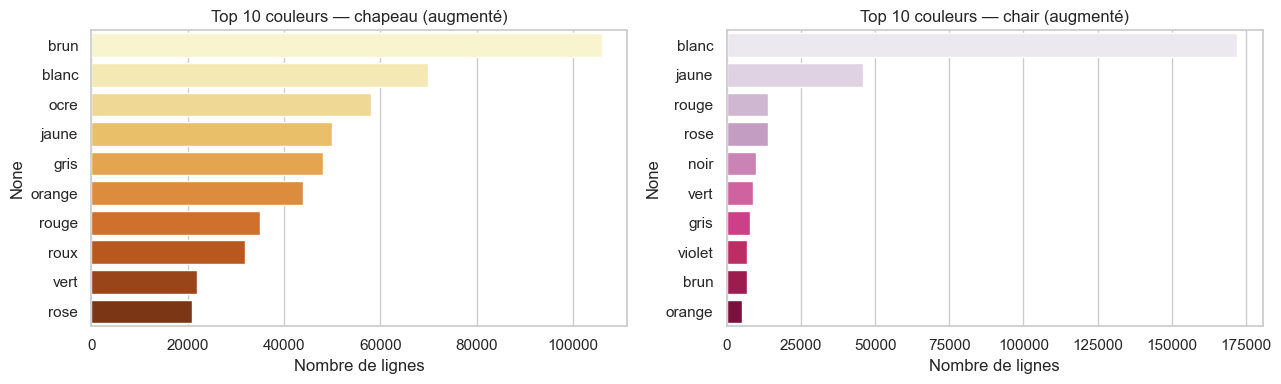

In [ ]:
def top_k_by_prefix(data, prefix, k=10):
    cols = [c for c in data.columns if c.startswith(prefix)]
    counts = data[cols].sum().sort_values(ascending=False).head(k)
    counts.index = [c.replace(prefix, "") for c in counts.index]
    return counts

chapeau_top = top_k_by_prefix(df, "chapeau_couleur_", k=10)
chair_top   = top_k_by_prefix(df, "chair_couleur_",   k=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(x=chapeau_top.values, y=chapeau_top.index, ax=axes[0], palette="YlOrBr")
axes[0].set_title("Top 10 couleurs — chapeau (augmenté)")
axes[0].set_xlabel("Nombre de lignes")

sns.barplot(x=chair_top.values, y=chair_top.index, ax=axes[1], palette="PuRd")
axes[1].set_title("Top 10 couleurs — chair (augmenté)")
axes[1].set_xlabel("Nombre de lignes")

plt.tight_layout()
plt.show()

### 3.3 Saisons (mois d'apparition)

Rappel : l'augmentation tire **un seul mois** parmi les mois actifs de l'espèce → la somme par mois ici reflète la distribution réelle pondérée par les espèces.

C:\Users\benja\AppData\Local\Temp\ipykernel_1928\3446491889.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mois_labels, y=season_counts.values, ax=ax, palette="crest")


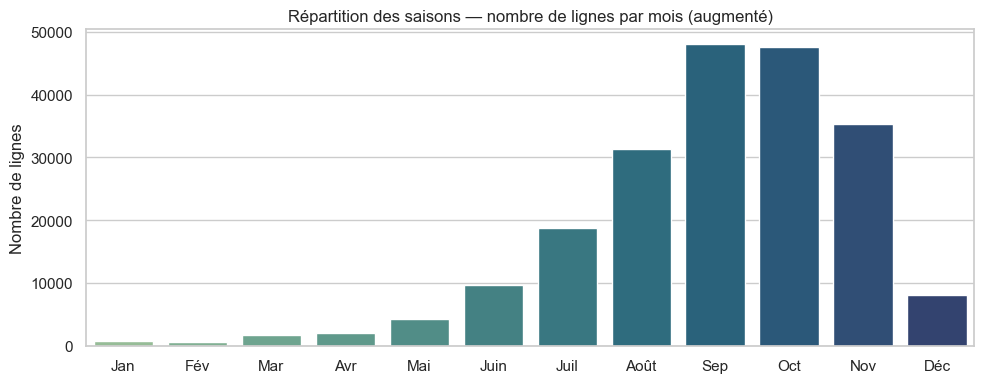

In [ ]:
season_cols = [f"saison_mois_{i:02d}" for i in range(1, 13)]
season_counts = df[season_cols].sum()
mois_labels = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=mois_labels, y=season_counts.values, ax=ax, palette="crest")
ax.set_title("Répartition des saisons — nombre de lignes par mois (augmenté)")
ax.set_ylabel("Nombre de lignes")
plt.tight_layout()
plt.show()

### 3.4 Habitats

C:\Users\benja\AppData\Local\Temp\ipykernel_1928\1970366925.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=habitat_counts.values, y=habitat_counts.index, ax=ax, palette="mako")


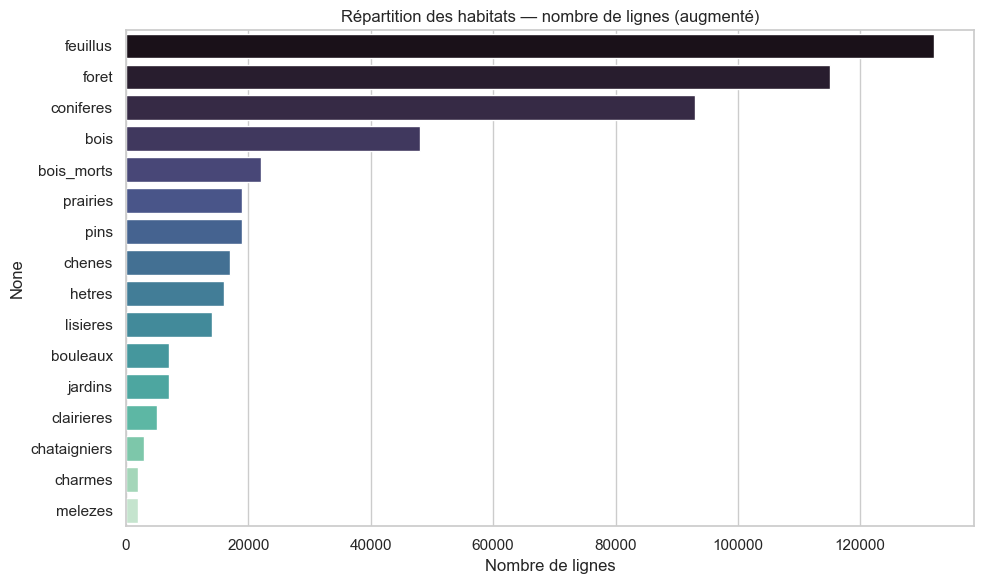

In [ ]:
habitat_counts = top_k_by_prefix(df, "habitat_type_", k=16)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=habitat_counts.values, y=habitat_counts.index, ax=ax, palette="mako")
ax.set_title("Répartition des habitats — nombre de lignes (augmenté)")
ax.set_xlabel("Nombre de lignes")
plt.tight_layout()
plt.show()

## 4. Analyse de la cible

### 4.1 Cible = `nom` — vérification de l'équilibre

L'augmentation est paramétrée pour produire **N lignes par espèce** : on attend donc une répartition parfaitement équilibrée.

Nombre d'espèces distinctes : 217
Lignes par espèce — min : 1000, max : 1000, moyenne : 1000.00


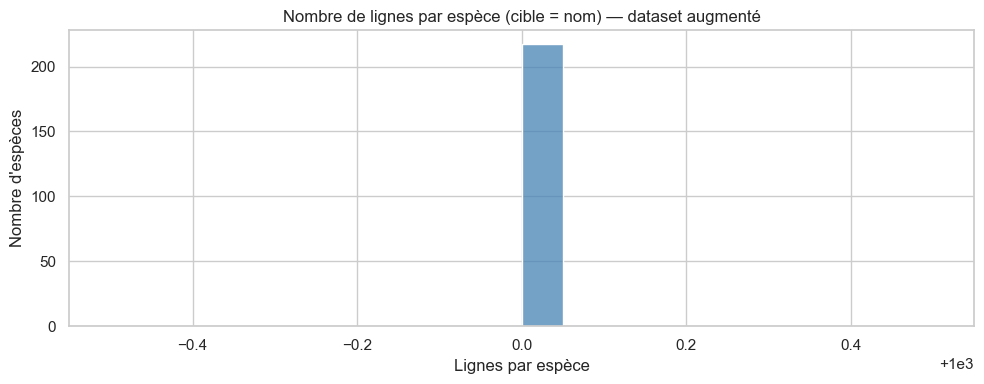

In [ ]:
nom_counts = df["nom"].value_counts()
print(f"Nombre d'espèces distinctes : {nom_counts.shape[0]}")
print(f"Lignes par espèce — min : {nom_counts.min()}, max : {nom_counts.max()}, moyenne : {nom_counts.mean():.2f}")

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(nom_counts.values, bins=20, ax=ax, color="steelblue")
ax.set_title("Nombre de lignes par espèce (cible = nom) — dataset augmenté")
ax.set_xlabel("Lignes par espèce")
ax.set_ylabel("Nombre d'espèces")
plt.tight_layout()
plt.show()

### 4.2 Cible = `statut`

statut
Champignon à rejeter          73000
Les bons champignons          50000
Les champignons toxiques      34000
Les champignons mediocres     33000
Les excellents champignons    18000
Les champignons mortel         9000
Name: count, dtype: int64


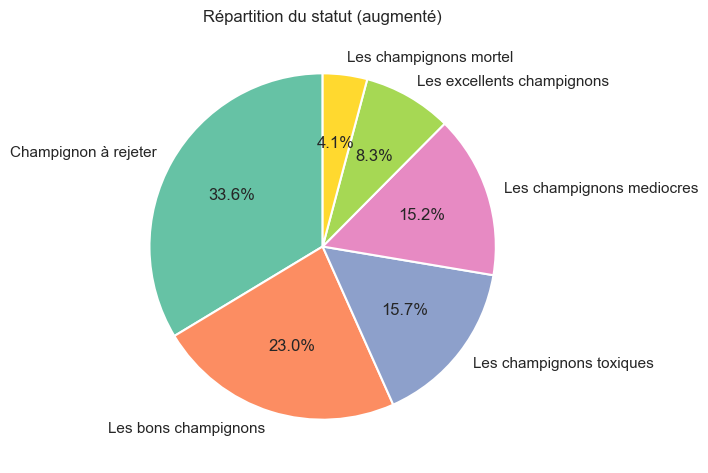

In [ ]:
statut_counts = df["statut"].value_counts()
print(statut_counts)

fig, ax = plt.subplots(figsize=(7, 7))
colors = sns.color_palette("Set2", n_colors=len(statut_counts))
ax.pie(
    statut_counts.values,
    labels=statut_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax.set_title("Répartition du statut (augmenté)")
plt.tight_layout()
plt.show()

## 5. Comparaison synthétique vs réel

Le CSV réel (`champignons_clean.csv`) fournit encore `*_taille_min_cm` / `*_taille_max_cm` par espèce. On compare :
- la distribution des tirages uniformes du dataset augmenté, à
- un tirage uniforme équivalent `U(min, max)` reconstruit à partir du réel pour rester sur la même échelle (une mesure par espèce).

Si l'augmentation est correcte, les deux distributions doivent être statistiquement proches.

### 5.1 Moyennes des tailles

In [ ]:
rng = np.random.default_rng(42)

# Reconstruit une taille "one-shot" côté réel : U(min, max) par espèce
def uniform_from_range(df_src, part):
    vmin = df_src[f"{part}_taille_min_cm"].to_numpy(dtype=float)
    vmax = df_src[f"{part}_taille_max_cm"].to_numpy(dtype=float)
    u = rng.uniform(size=len(df_src))
    return vmin + u * (vmax - vmin)

df_clean = df_clean.copy()
df_clean["chapeau_taille_cm"] = uniform_from_range(df_clean, "chapeau")
df_clean["pied_taille_cm"]    = uniform_from_range(df_clean, "pied")

cols = ["chapeau_taille_cm", "pied_taille_cm"]
compare = pd.DataFrame({
    "réel_mean":     df_clean[cols].mean(),
    "augmenté_mean": df[cols].mean(),
    "réel_std":      df_clean[cols].std(),
    "augmenté_std":  df[cols].std(),
})
compare["delta_mean"] = compare["augmenté_mean"] - compare["réel_mean"]
compare["delta_pct"]  = 100 * compare["delta_mean"] / compare["réel_mean"]
compare.round(3)

In [ ]:
means_df = (
    compare[["réel_mean", "augmenté_mean"]]
    .reset_index()
    .rename(columns={"index": "colonne"})
    .melt(id_vars="colonne", var_name="dataset", value_name="moyenne")
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=means_df, x="colonne", y="moyenne", hue="dataset", ax=ax, palette="Set1")
ax.set_title("Moyenne des tailles — réel (U(min,max)) vs augmenté")
ax.set_ylabel("cm")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 5.2 Distributions superposées

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(df_clean["chapeau_taille_cm"].dropna(), ax=axes[0], label="réel (U(min,max))", color="darkblue",  fill=True, alpha=0.3)
sns.kdeplot(sample["chapeau_taille_cm"],            ax=axes[0], label="augmenté",         color="orangered", fill=True, alpha=0.3)
axes[0].set_title("chapeau_taille_cm — densité")
axes[0].set_xlabel("cm")
axes[0].legend()

sns.kdeplot(df_clean["pied_taille_cm"].dropna(), ax=axes[1], label="réel (U(min,max))", color="darkblue",  fill=True, alpha=0.3)
sns.kdeplot(sample["pied_taille_cm"],            ax=axes[1], label="augmenté",         color="orangered", fill=True, alpha=0.3)
axes[1].set_title("pied_taille_cm — densité")
axes[1].set_xlabel("cm")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.3 Moyenne par espèce — réel vs augmenté

Pour chaque espèce, on compare la taille moyenne attendue (milieu de l'intervalle réel = `(min+max)/2`) à la moyenne des 1000 tirages augmentés. Les points doivent s'aligner sur la diagonale : une dérive forte signalerait un bug de l'augmentation.

In [ ]:
# Référence réelle : milieu de l'intervalle (min+max)/2 par espèce
ref = df_clean.set_index("nom").copy()
ref["chapeau_mid"] = (ref["chapeau_taille_min_cm"] + ref["chapeau_taille_max_cm"]) / 2
ref["pied_mid"]    = (ref["pied_taille_min_cm"]    + ref["pied_taille_max_cm"])    / 2

per_species = (
    df.groupby("nom")[["chapeau_taille_cm", "pied_taille_cm"]]
      .mean()
      .rename(columns={"chapeau_taille_cm": "chapeau_aug", "pied_taille_cm": "pied_aug"})
      .join(ref[["chapeau_mid", "pied_mid"]].rename(columns={"chapeau_mid": "chapeau_reel", "pied_mid": "pied_reel"}))
      .dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(per_species["chapeau_reel"], per_species["chapeau_aug"], alpha=0.5, s=18, color="steelblue")
lim = [0, per_species[["chapeau_reel", "chapeau_aug"]].max().max() * 1.05]
axes[0].plot(lim, lim, "--", color="grey", label="y = x")
axes[0].set_xlabel("Réel — (min+max)/2 (cm)")
axes[0].set_ylabel("Augmenté — moyenne (cm)")
axes[0].set_title("chapeau_taille_cm — moyenne par espèce")
axes[0].legend()

axes[1].scatter(per_species["pied_reel"], per_species["pied_aug"], alpha=0.5, s=18, color="darkorange")
lim = [0, per_species[["pied_reel", "pied_aug"]].max().max() * 1.05]
axes[1].plot(lim, lim, "--", color="grey", label="y = x")
axes[1].set_xlabel("Réel — (min+max)/2 (cm)")
axes[1].set_ylabel("Augmenté — moyenne (cm)")
axes[1].set_title("pied_taille_cm — moyenne par espèce")
axes[1].legend()

plt.tight_layout()
plt.show()

delta_chapeau = (per_species["chapeau_aug"] - per_species["chapeau_reel"]).abs().mean()
delta_pied    = (per_species["pied_aug"]    - per_species["pied_reel"]).abs().mean()
print(f"Écart moyen absolu par espèce — chapeau : {delta_chapeau:.3f} cm | pied : {delta_pied:.3f} cm")